# Notebook 01 - Analisi Esplorativa dei Dati (EDA)

## Scopo del notebook

Questo e' il **primo notebook** della pipeline: prima di tuffarci in
preprocessing e modelli, dobbiamo *capire* il dataset. L'EDA (Exploratory
Data Analysis) risponde a domande come:

- Quante immagini abbiamo per ciascuna classe (COVID vs non-COVID)? Il
  dataset e' bilanciato o sbilanciato?
- Le immagini hanno dimensioni omogenee, o c'e' alta varianza?
- Le distribuzioni di intensita' dei pixel sono simili fra le due classi,
  o ci sono potenziali **shortcut** (es. immagini COVID sistematicamente
  piu' luminose, cosa che il modello potrebbe imparare al posto della
  vera patologia)?

## Prerequisiti

Prima di lanciare questo notebook esegui:

```
PYTHONPATH=. python scripts/prepare_data.py
```

che genera i CSV `data/processed/{train,val,test}.csv`.

## Output

Le figure prodotte vengono salvate in `docs/figures/` e finiscono nel
report tecnico.


## Setup: import e caricamento dei CSV degli split

In [1]:
# Import standard per data science: pathlib per i path, numpy/pandas per i
# dati, matplotlib per i grafici, PIL per leggere le dimensioni dei PNG senza
# caricare i pixel.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Il notebook gira da `notebooks/`, quindi la root del progetto e' una
# directory sopra (`..`).
ROOT = Path("..")
PROCESSED = ROOT / "data" / "processed"

# Concateniamo i tre CSV in un unico DataFrame per l'analisi globale.
df = pd.concat(
    [pd.read_csv(PROCESSED / f"{s}.csv") for s in ("train", "val", "test")],
    ignore_index=True,
)
# I path nei CSV sono relativi alla root del progetto; aggiungiamo
# `abs_path` con il path corretto per il notebook (che gira in `notebooks/`).
df["abs_path"] = df["filepath"].apply(lambda p: ROOT / p)
print(f"Total images: {len(df)}")
df.head()


Total images: 2481


,filepath,label,split,abs_path
0,sarscov2-ctscan-dataset\COVID\Covid (370).png,covid,train,..\sarscov2-ctscan-dataset\COVID\Covid (370).png
1,sarscov2-ctscan-dataset\COVID\Covid (1057).png,covid,train,..\sarscov2-ctscan-dataset\COVID\Covid (1057).png
2,sarscov2-ctscan-dataset\COVID\Covid (721).png,covid,train,..\sarscov2-ctscan-dataset\COVID\Covid (721).png
3,sarscov2-ctscan-dataset\non-COVID\Non-Covid (7...,non-covid,train,..\sarscov2-ctscan-dataset\non-COVID\Non-Covid...
4,sarscov2-ctscan-dataset\non-COVID\Non-Covid (7...,non-covid,train,..\sarscov2-ctscan-dataset\non-COVID\Non-Covid...


## 1. Distribuzione delle classi

**Cosa stiamo cercando**: il rapporto fra immagini COVID e non-COVID nel
dataset. Se uno sbilanciamento e' forte (es. 90/10), dobbiamo:
- usare metriche robuste come ROC-AUC e AP (non solo accuracy),
- considerare class weights o resampling in fase di training.


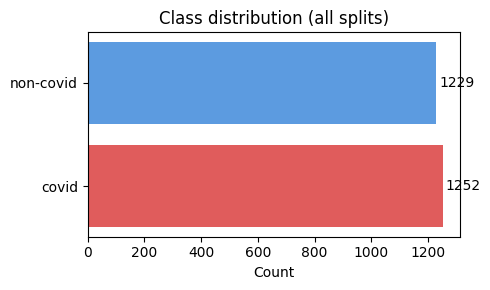

In [2]:
# `value_counts()` di pandas conta le occorrenze di ciascuna label.
counts = df["label"].value_counts()

# Barplot orizzontale: piu' leggibile delle label se i nomi sono lunghi.
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.barh(counts.index, counts.values, color=["#e05c5c", "#5c9be0"])
# Annotiamo ogni barra con il valore numerico, posizionato leggermente
# a destra dell'estremo della barra.
for bar, v in zip(bars, counts.values):
    ax.text(v + 10, bar.get_y() + bar.get_height() / 2, str(v), va="center")
ax.set_xlabel("Count")
ax.set_title("Class distribution (all splits)")
plt.tight_layout()
plt.savefig(ROOT / "docs" / "figures" / "class_distribution.png", dpi=150)
plt.show()


## 2. Distribuzione delle dimensioni originali

**Cosa stiamo cercando**: se le immagini hanno dimensioni molto eterogenee,
il resize a 224x224 (con padding) introdurra' diversi gradi di "perdita
di informazione" a seconda dei sample. Inoltre, se le dimensioni
correlassero con la classe, sarebbe un altro potenziale **shortcut**.

Per non rallentare il notebook leggiamo le dimensioni solo su un
sub-sample di 300 immagini.


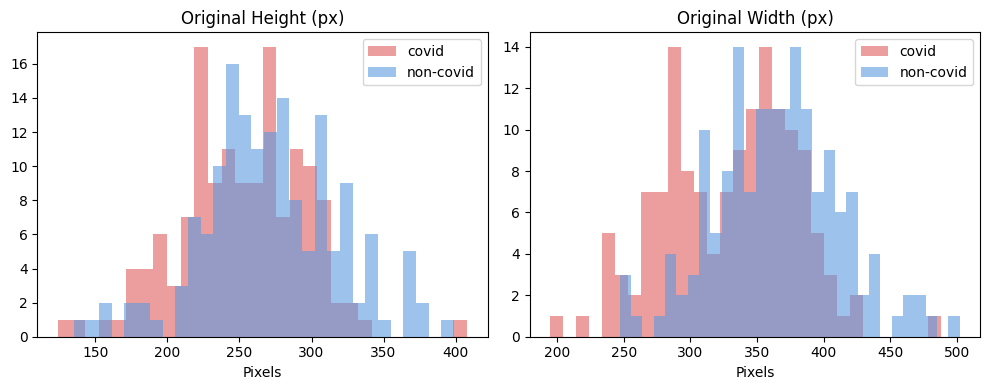

In [3]:
# Sub-sample di 300 immagini per velocita' (su ~2500 totali). Seed 42.
rng = np.random.default_rng(42)
sample = df.sample(min(300, len(df)), random_state=42)

# `Image.open` con context manager: legge solo l'header (rapidissimo),
# non i pixel.
heights, widths = [], []
for p in sample["abs_path"]:
    with Image.open(p) as img:
        w, h = img.size
    heights.append(h)
    widths.append(w)
sample = sample.copy()  # evita SettingWithCopyWarning
sample["height"] = heights
sample["width"] = widths

# Due subplot affiancati: altezze a sx, larghezze a dx.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for label, color in [("covid", "#e05c5c"), ("non-covid", "#5c9be0")]:
    sub = sample[sample["label"] == label]
    # `alpha=0.6` per trasparenza: si vede la sovrapposizione fra classi.
    axes[0].hist(sub["height"], bins=30, alpha=0.6, color=color, label=label)
    axes[1].hist(sub["width"], bins=30, alpha=0.6, color=color, label=label)
for ax, title in zip(axes, ["Original Height (px)", "Original Width (px)"]):
    ax.set_title(title)
    ax.set_xlabel("Pixels")
    ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "docs" / "figures" / "size_distribution.png", dpi=150)
plt.show()


## 3. Visualizzazione di immagini campione

**Cosa stiamo cercando**: ispezione visuale del dataset. Cose da notare:
- Le immagini sono effettivamente CT del torace o ci sono artefatti?
- Le scritte/annotazioni cliniche introducono shortcut?
- C'e' una distinzione visiva apparente fra COVID e non-COVID?


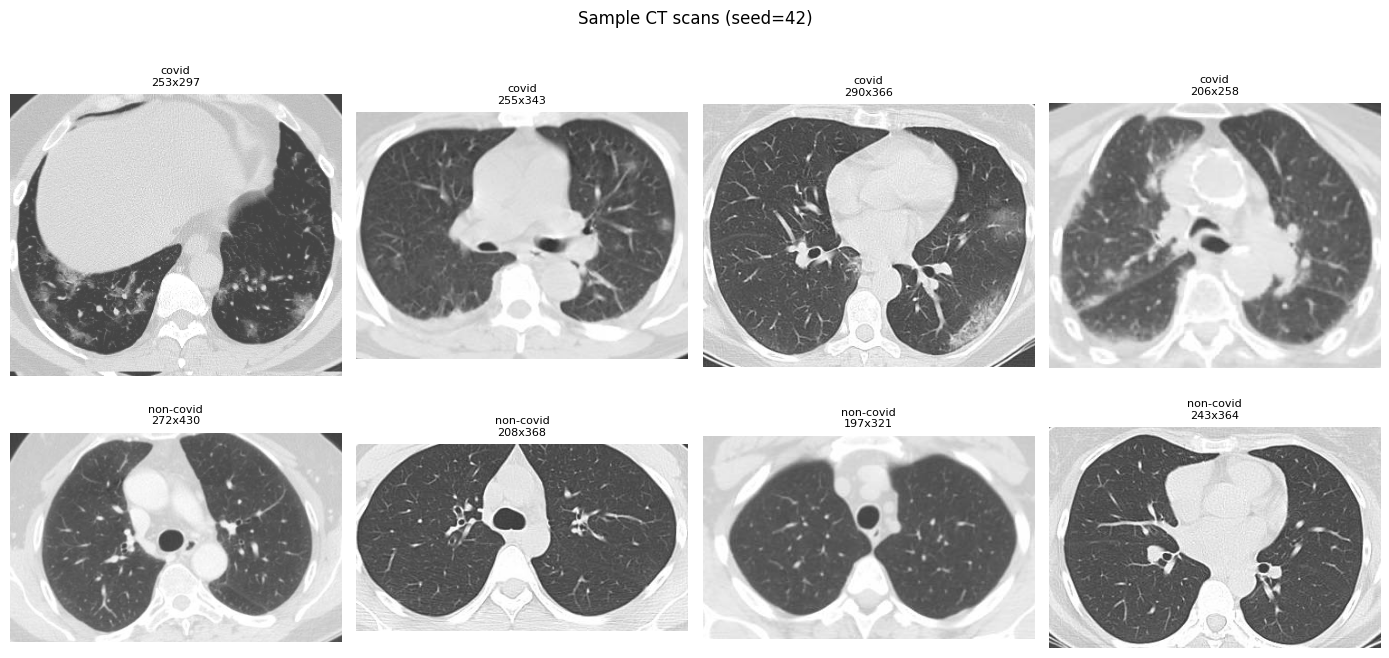

In [4]:
# Griglia 2x4: prima riga COVID, seconda non-COVID.
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, label in enumerate(["covid", "non-covid"]):
    subset = df[df["label"] == label].sample(4, random_state=42)
    for col, (_, row_data) in enumerate(subset.iterrows()):
        with Image.open(row_data["abs_path"]) as img:
            # `cmap="gray"` per il rendering corretto (di default matplotlib
            # applica "viridis" che falsifica i toni di grigio).
            axes[row, col].imshow(img, cmap="gray")
            axes[row, col].set_title(f"{label}\n{img.height}x{img.width}", fontsize=8)
            axes[row, col].axis("off")
plt.suptitle("Sample CT scans (seed=42)", y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "docs" / "figures" / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Istogramma di intensita' medio per classe

**Cosa stiamo cercando**: shortcut basati sulla luminosita'. Se la curva
COVID e' sistematicamente spostata rispetto alla curva non-COVID, il
modello potrebbe usare la "luminosita' media" come segnale anziche'
imparare le caratteristiche cliniche reali (ground-glass, consolidamenti).

- Curve visivamente sovrapposte -> rischio shortcut basso.
- Curve spostate -> documentalo nel report come limitazione.


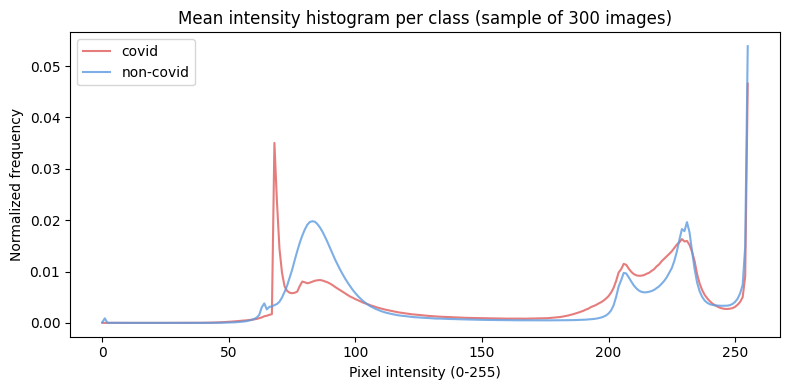

If the curves differ substantially (e.g. shifted brightness), report it as a potential shortcut in the technical analysis.


In [5]:
# Istogramma a 256 bin (uno per ciascun valore uint8).
bins = np.arange(257)
# Accumulatori per classe.
hist_acc = {"covid": np.zeros(256), "non-covid": np.zeros(256)}
counts_acc = {"covid": 0, "non-covid": 0}

for label in ["covid", "non-covid"]:
    subset = df[df["label"] == label].sample(min(300, (df["label"] == label).sum()), random_state=42)
    for p in subset["abs_path"]:
        with Image.open(p) as img:
            # `convert("L")` forza grayscale (sicurezza se l'immagine e' RGB).
            arr = np.array(img.convert("L"), dtype=np.float32)
        h, _ = np.histogram(arr.ravel(), bins=bins)
        hist_acc[label] += h
        counts_acc[label] += 1

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(256)
for label, color in [("covid", "#e05c5c"), ("non-covid", "#5c9be0")]:
    # Normalizziamo dividendo per la somma totale: rende le curve
    # confrontabili anche se le classi hanno numero diverso di sample.
    norm = hist_acc[label] / hist_acc[label].sum()
    ax.plot(x, norm, color=color, alpha=0.8, label=label)
ax.set_xlabel("Pixel intensity (0-255)")
ax.set_ylabel("Normalized frequency")
ax.set_title("Mean intensity histogram per class (sample of 300 images)")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "docs" / "figures" / "intensity_histogram.png", dpi=150)
plt.show()

print("If the curves differ substantially (e.g. shifted brightness), "
      "report it as a potential shortcut in the technical analysis.")
